## 0. Setup & Config

In [1]:
import importlib
import json
import subprocess
import sys
from pathlib import Path


def _import_or_install(import_name: str, package_name: str | None = None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name or import_name])
        return importlib.import_module(import_name)


np = _import_or_install("numpy")
pd = _import_or_install("pandas")
sklearn = _import_or_install("sklearn", "scikit-learn")
ce = _import_or_install("category_encoders", "category-encoders")
cb = _import_or_install("catboost")
lgb = _import_or_install("lightgbm")
matplotlib = _import_or_install("matplotlib")
plt = importlib.import_module("matplotlib.pyplot")
optuna = _import_or_install("optuna")
sns = _import_or_install("seaborn")
xgb = _import_or_install("xgboost")

In [2]:
DATA_DIR = Path('/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track')
OUTPUT_DIR = Path('/kaggle/working/')
CHARTS_DIR = OUTPUT_DIR / 'charts'
MODELS_DIR = OUTPUT_DIR / 'models'
RAW_TRAIN_PATH = DATA_DIR / 'train.csv'
RAW_TEST_PATH = DATA_DIR / 'test.csv'
SAMPLE_SUBMISSION_PATH = DATA_DIR / 'sample_submission.csv'

In [3]:
train = pd.read_csv(RAW_TRAIN_PATH)
test = pd.read_csv(RAW_TEST_PATH)

print(train.shape)
print(test.shape)

(6818, 13)
(1705, 12)


In [4]:
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## 1. EDA & Structural Diagnostics

In [5]:
PRODUCT_KEY = 'product_code'
STORE_KEY = 'store_code'
CATEGORY_KEY = 'product_category'
TARGET_KEY = 'total_sales'

In [6]:
def audit_dataframe(df, name):
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(dropna=False),
    })
    print(f'\n{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
    print(f'Duplicated rows: {df.duplicated().sum():,}')
    display(summary.sort_values(['missing_count', 'n_unique'], ascending=False))

audit_dataframe(train, 'TRAIN')
audit_dataframe(test, 'TEST')


TRAIN: 6,818 rows x 13 columns
Duplicated rows: 0


,dtype,missing_count,missing_pct,n_unique
store_size,object,1919,28.15,4
product_weight_kg,float64,1225,17.97,4676
id,object,0,0.00,6818
total_sales,float64,0,0.00,6776
product_price,float64,0,0.00,5818
shelf_visibility,float64,0,0.00,1732
product_code,object,0,0.00,1555
product_category,object,0,0.00,48
store_code,object,0,0.00,10
store_age_years,int64,0,0.00,9



TEST: 1,705 rows x 12 columns
Duplicated rows: 0


,dtype,missing_count,missing_pct,n_unique
store_size,object,491,28.80,4
product_weight_kg,float64,306,17.95,1330
id,object,0,0.00,1705
product_price,float64,0,0.00,1650
product_code,object,0,0.00,1082
shelf_visibility,float64,0,0.00,984
product_category,object,0,0.00,48
store_code,object,0,0.00,10
store_age_years,int64,0,0.00,9
store_format,object,0,0.00,4


In [7]:
categorical_cols_raw = train.select_dtypes(include='object').columns.tolist()
for col in categorical_cols_raw:
    print(f'\n{col} ({train[col].nunique(dropna=False)} unique values)')
    display(train[col].value_counts(dropna=False).head(20).to_frame('count'))


id (6818 unique values)


,count
id,
row_08522,1
row_00000,1
row_08505,1
row_08503,1
row_08502,1
row_08501,1
row_08500,1
row_08499,1
row_08498,1



product_code (1555 unique values)


,count
product_code,
PRD-YZB4K8,9
PRD-U02KQN,8
PRD-8INI8M,8
PRD-U438R9,8
PRD-ONGWUL,8
PRD-1RUPFR,8
PRD-8A5PN4,8
PRD-1ZL2WT,8
PRD-MH7GX8,8



fat_content (2 unique values)


...

,count
store_size,
Medium,2218
Small,1933
NaN,1919
Large,748



store_location_tier (3 unique values)


,count
store_location_tier,
Tier_3,2677
Tier_2,2232
Tier_1,1909



store_format (4 unique values)


,count
store_format,
Standard Supermarket,4462
Corner Shop,866
Flagship Hypermarket,748
Superstore,742


In [8]:
missing_cols = ['product_code', 'store_code', 'product_category', 'fat_content', 'store_format', 'store_location_tier', 'store_size']

print('Train missingness')
print(train.isnull().sum())
print()
print('Test missingness')
print(test.isnull().sum())
print()

for name, frame in [('train', train), ('test', test)]:
    print(f'{name} cardinality')
    print(frame[missing_cols].nunique())
    print()

Train missingness
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Test missingness
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64

train cardinality
product_code           1555
store_code               10
product_category         48
fat_content               2
store_format              4
store_location_tier       3
store_size                3
dtype: int64

test cardinality
prod

In [9]:
store_overlap = set(test[STORE_KEY]) <= set(train[STORE_KEY])
store_cold_start_count = len(set(test[STORE_KEY]) - set(train[STORE_KEY]))
print('store_overlap:', store_overlap)
print('store_cold_start_count:', store_cold_start_count)

store_overlap: True
store_cold_start_count: 0


In [10]:
product_overlap = set(test[PRODUCT_KEY]) <= set(train[PRODUCT_KEY])
product_cold_start_count = len(set(test[PRODUCT_KEY]) - set(train[PRODUCT_KEY]))
print('product_overlap:', product_overlap)
print('product_cold_start_count:', product_cold_start_count)

product_overlap: False
product_cold_start_count: 4


In [11]:
pair_counts = train.groupby([PRODUCT_KEY, STORE_KEY]).size()
print(pair_counts.describe())
print('max_pair_count:', pair_counts.max())
max_pair_count = pair_counts.max()

count    6818.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
dtype: float64
max_pair_count: 1


In [12]:
store_size_summary = train.groupby(STORE_KEY)['store_size'].agg(
    nunique_non_null=lambda s: s.dropna().nunique(),
    missing_rows=lambda s: s.isna().sum(),
)
stores_missing_size = store_size_summary[store_size_summary['missing_rows'] > 0].index.tolist()
print(store_size_summary)
print('stores_missing_size:', stores_missing_size)

            nunique_non_null  missing_rows
store_code                                
STORE-7WS                  1             0
STORE-89Z                  1             0
STORE-9RG                  1             0
STORE-AGY                  1             0
STORE-DKU                  0           736
STORE-HL7                  1             0
STORE-JOR                  0           439
STORE-OYG                  0           744
STORE-T5G                  1             0
STORE-YLW                  1             0
stores_missing_size: ['STORE-DKU', 'STORE-JOR', 'STORE-OYG']


In [13]:
all_sales = pd.concat([
    train.drop(columns=[TARGET_KEY]),
    test,
], ignore_index=True)

weight_summary = all_sales.groupby(PRODUCT_KEY)['product_weight_kg'].agg(
    missing_rows=lambda s: s.isna().sum(),
    total_rows='size',
)
products_fully_missing_weight = weight_summary.index[weight_summary['missing_rows'] == weight_summary['total_rows']].tolist()
print(weight_summary.head())
print('products_fully_missing_weight_count:', len(products_fully_missing_weight))
print('products_fully_missing_weight:', products_fully_missing_weight)

              missing_rows  total_rows
product_code                          
PRD-00CVW9               0           5
PRD-00EIUE               2           6
PRD-00V830               1           2
PRD-02NFGI               3           7
PRD-031L36               2           6
products_fully_missing_weight_count: 4
products_fully_missing_weight: ['PRD-7JH2LK', 'PRD-DH3TKZ', 'PRD-E6K088', 'PRD-GSRI2A']


In [14]:
train['product_category_normalized'] = train[CATEGORY_KEY].str.lower().str.strip()
test['product_category_normalized'] = test[CATEGORY_KEY].str.lower().str.strip()

raw_nunique = train[CATEGORY_KEY].nunique()
normalized_nunique = train['product_category_normalized'].nunique()
product_categories_normalized = sorted(train['product_category_normalized'].dropna().unique().tolist())

print('raw_nunique:', raw_nunique)
print('normalized_nunique:', normalized_nunique)
print('product_categories_normalized:', product_categories_normalized)

raw_nunique: 48
normalized_nunique: 16
product_categories_normalized: ['baking goods', 'breads', 'breakfast', 'canned', 'dairy', 'frozen foods', 'fruits and vegetables', 'hard drinks', 'health and hygiene', 'household', 'meat', 'others', 'seafood', 'snack foods', 'soft drinks', 'starchy foods']


## Target Column

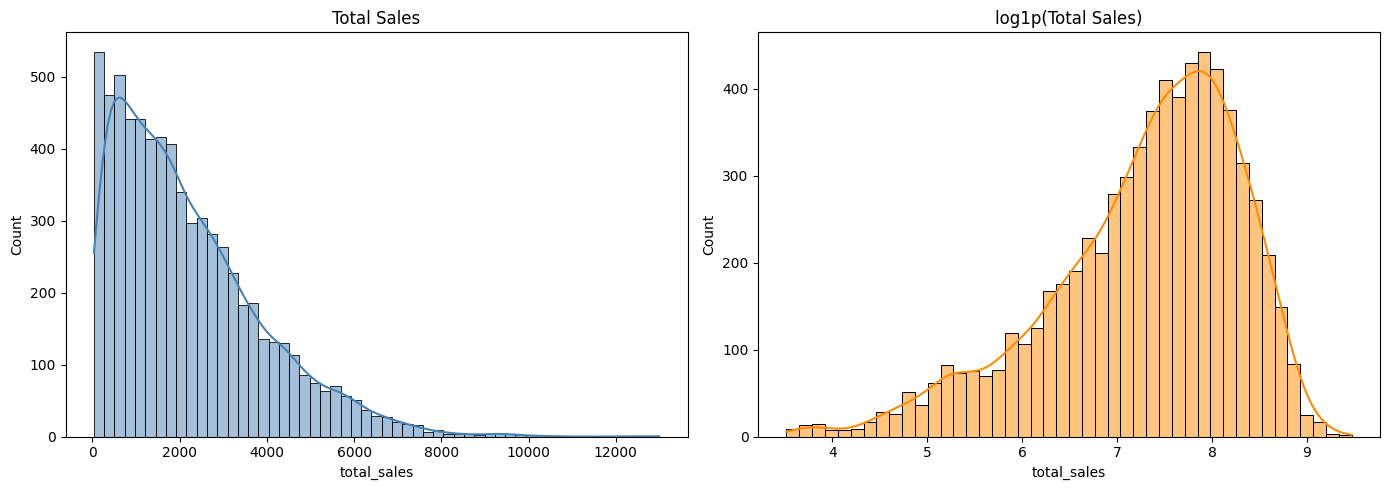

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

CHARTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET_KEY], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Total Sales')
sns.histplot(np.log1p(train[TARGET_KEY]), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(Total Sales)')
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')

In [16]:
print('sales_skew:', train[TARGET_KEY].skew())
print('log1p_sales_skew:', np.log1p(train[TARGET_KEY]).skew())

sales_skew: 1.1539947519138116
log1p_sales_skew: -0.8951280115081985


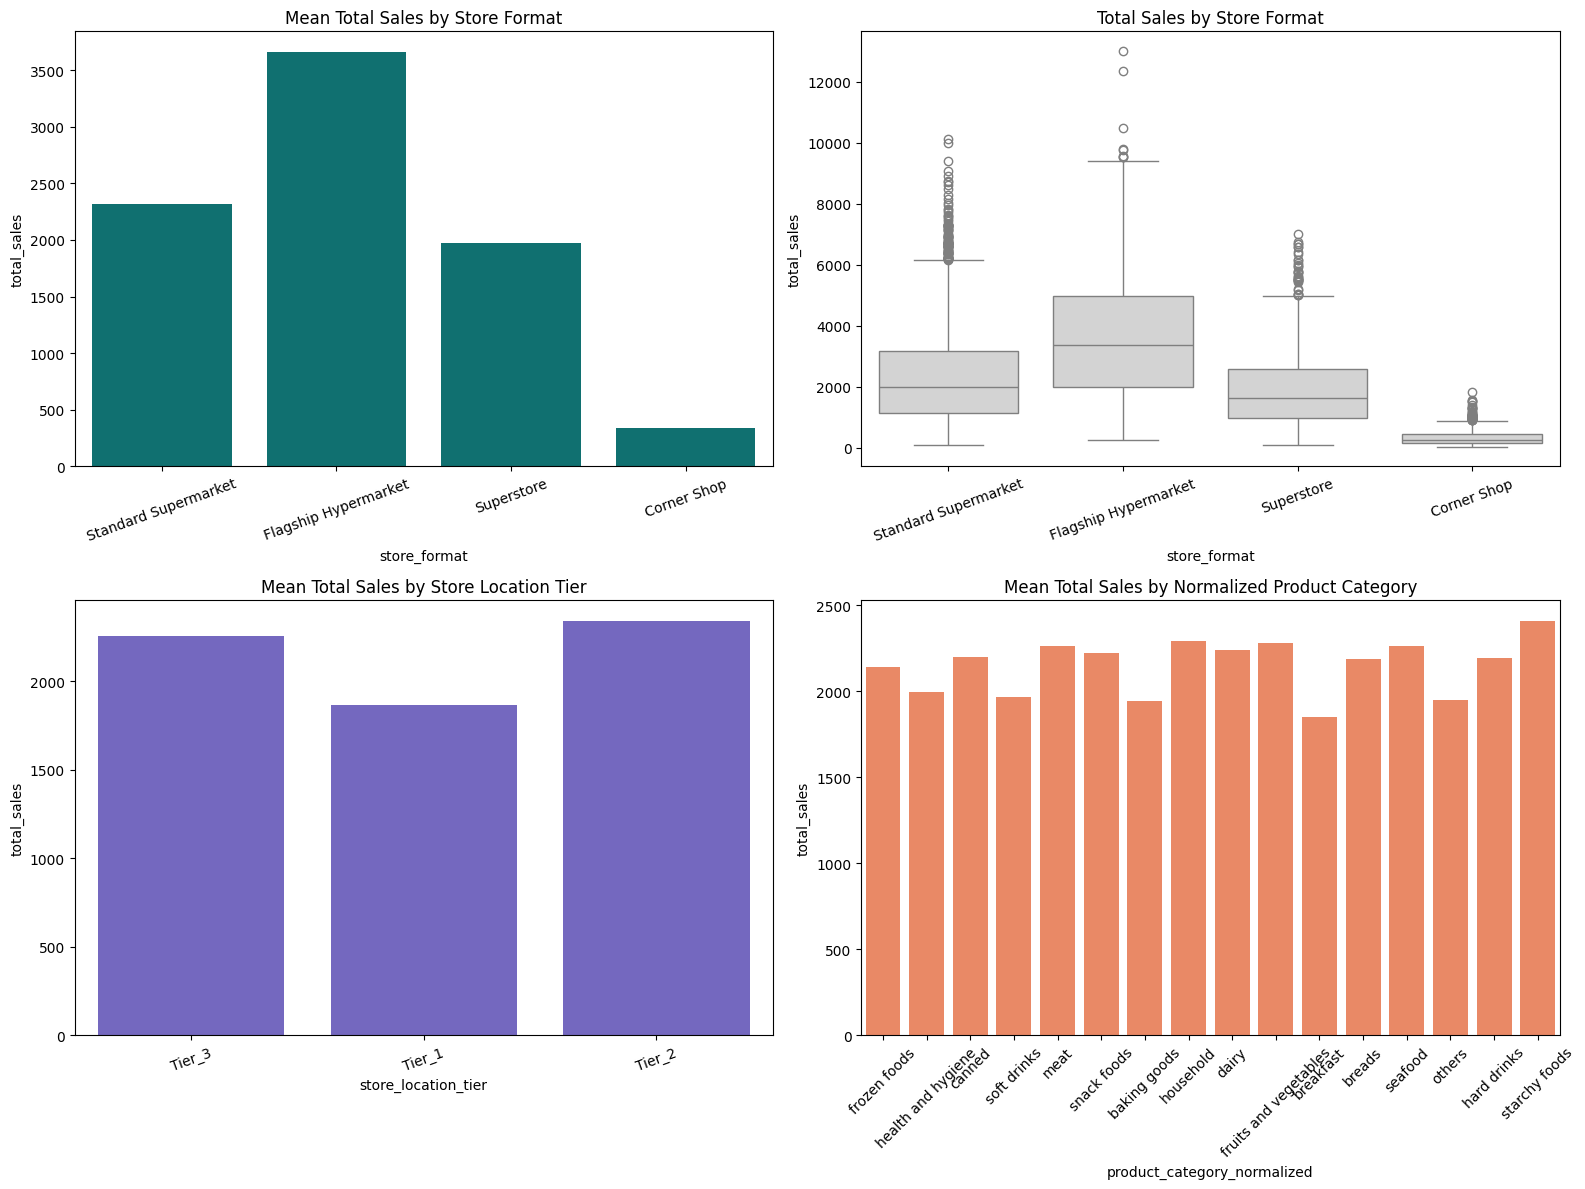

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=train, x='store_format', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Mean Total Sales by Store Format')
axes[0, 0].tick_params(axis='x', rotation=20)

sns.boxplot(data=train, x='store_format', y=TARGET_KEY, ax=axes[0, 1], color='lightgray')
axes[0, 1].set_title('Total Sales by Store Format')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.barplot(data=train, x='store_location_tier', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=axes[1, 0], color='slateblue')
axes[1, 0].set_title('Mean Total Sales by Store Location Tier')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.barplot(data=train, x='product_category_normalized', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Mean Total Sales by Normalized Product Category')
axes[1, 1].tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(CHARTS_DIR / 'sales_by_factors.png', dpi=150, bbox_inches='tight')
#plt.close(fig)

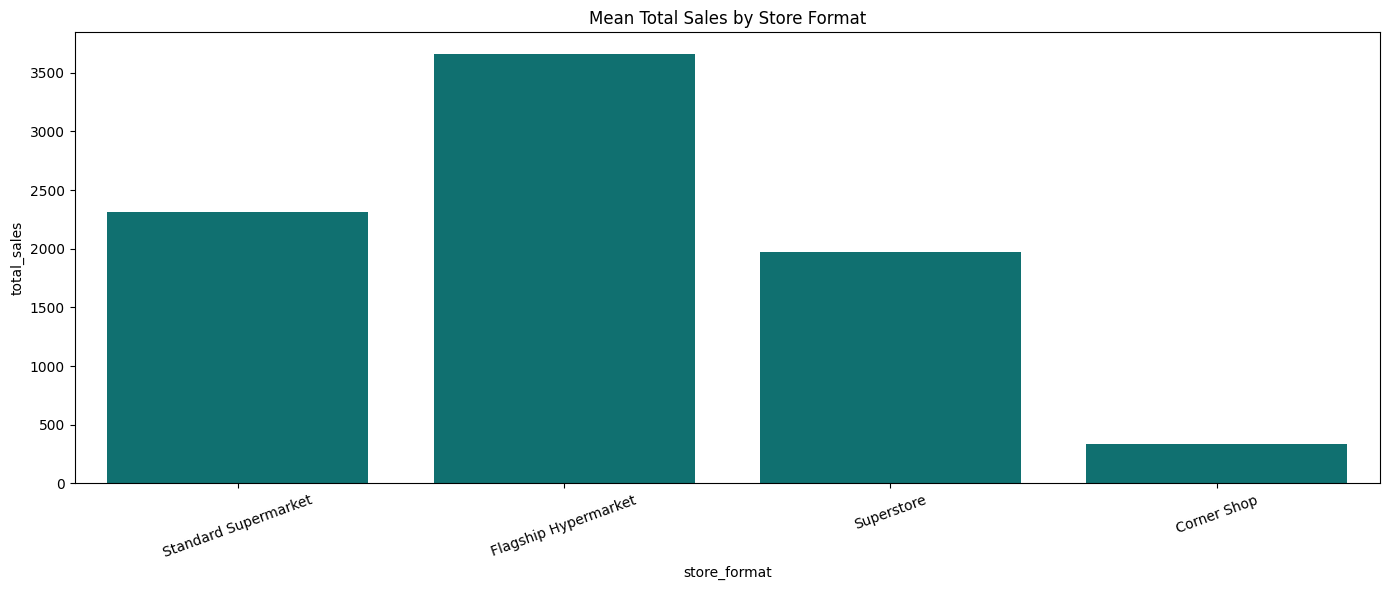

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=train, x='store_format', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=ax, color='teal')
ax.set_title('Mean Total Sales by Store Format')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'mean_sales_by_store_format.png', dpi=150, bbox_inches='tight')

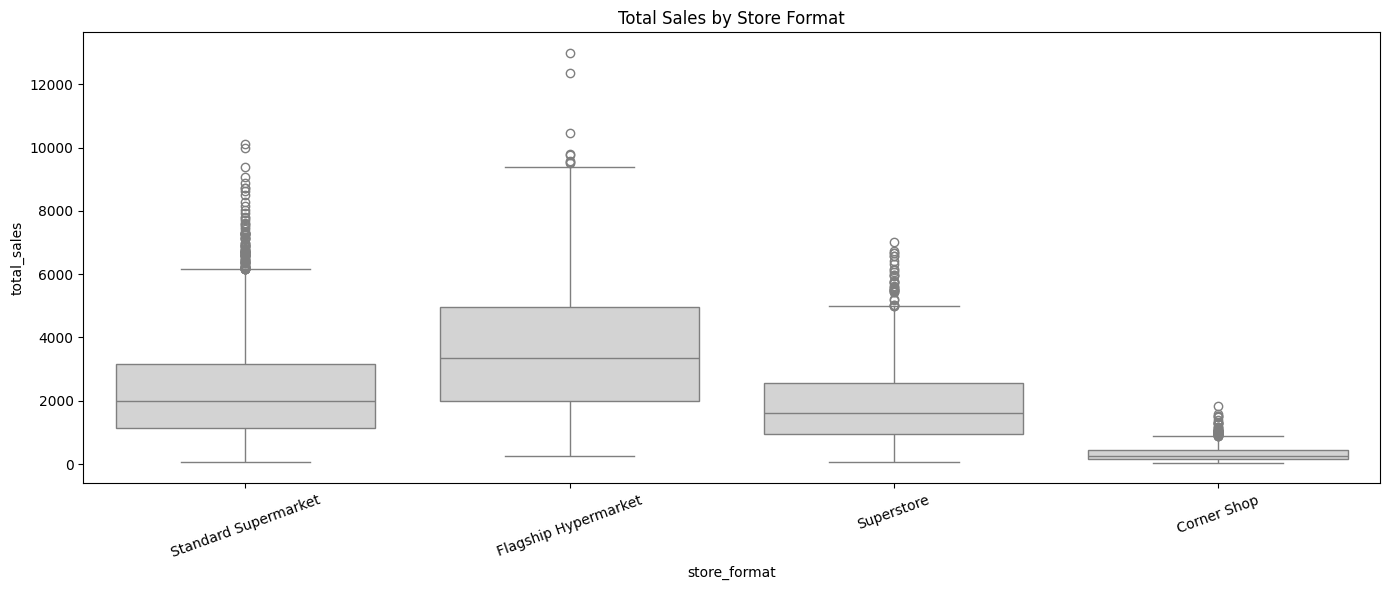

In [19]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=train, x='store_format', y=TARGET_KEY, ax=ax, color='lightgray')
ax.set_title('Total Sales by Store Format')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'boxplot_sales_by_store_format.png', dpi=150, bbox_inches='tight')

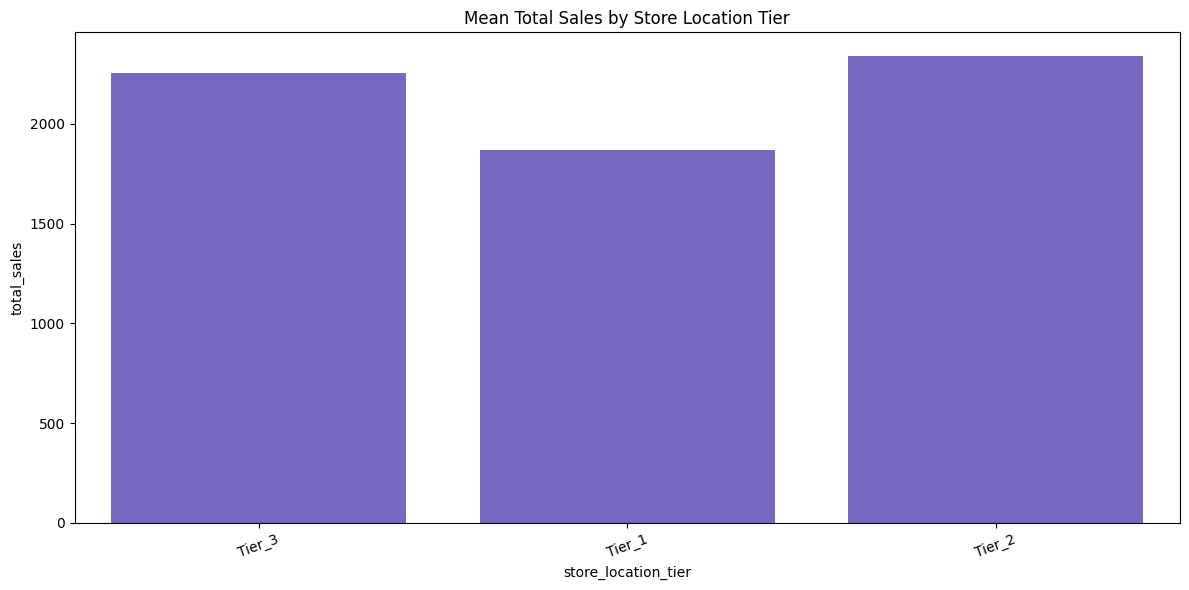

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=train, x='store_location_tier', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=ax, color='slateblue')
ax.set_title('Mean Total Sales by Store Location Tier')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'mean_sales_by_store_location_tier.png', dpi=150, bbox_inches='tight')

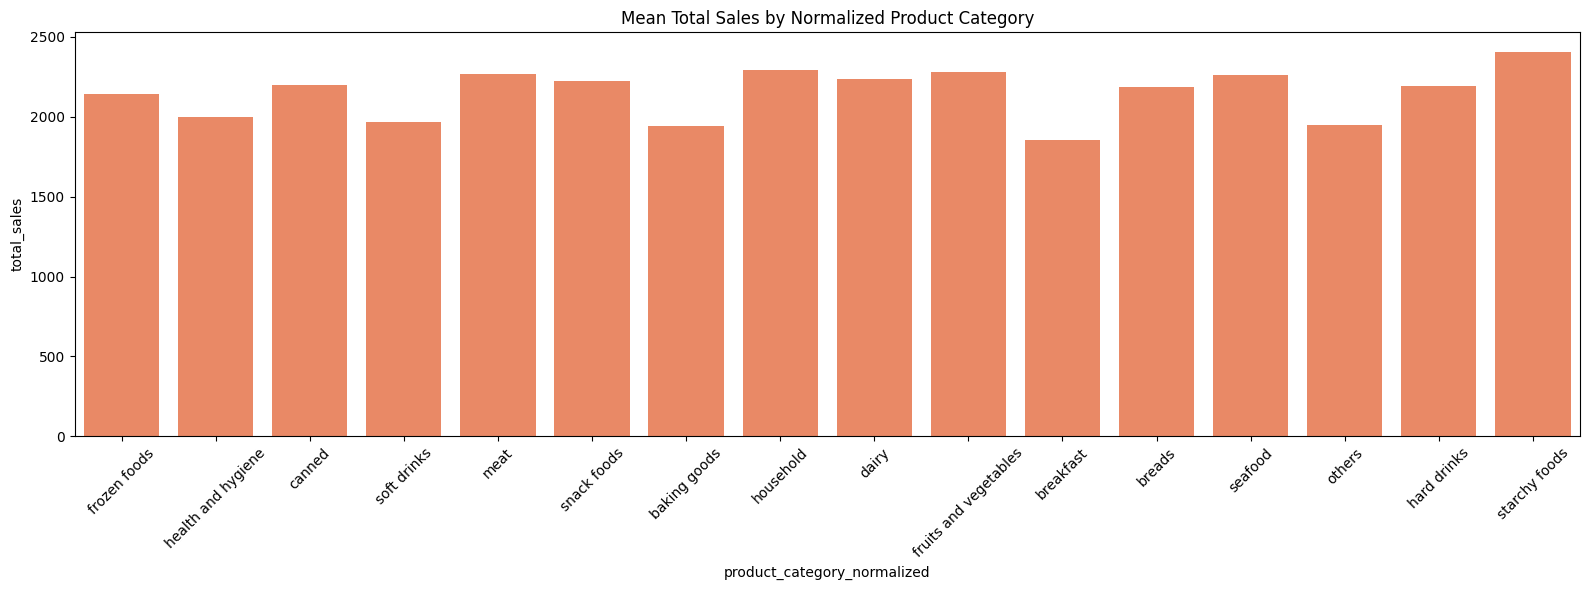

In [21]:
fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=train, x='product_category_normalized', y=TARGET_KEY, estimator=np.mean, errorbar=None, ax=ax, color='coral')
ax.set_title('Mean Total Sales by Normalized Product Category')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'mean_sales_by_product_category.png', dpi=150, bbox_inches='tight')

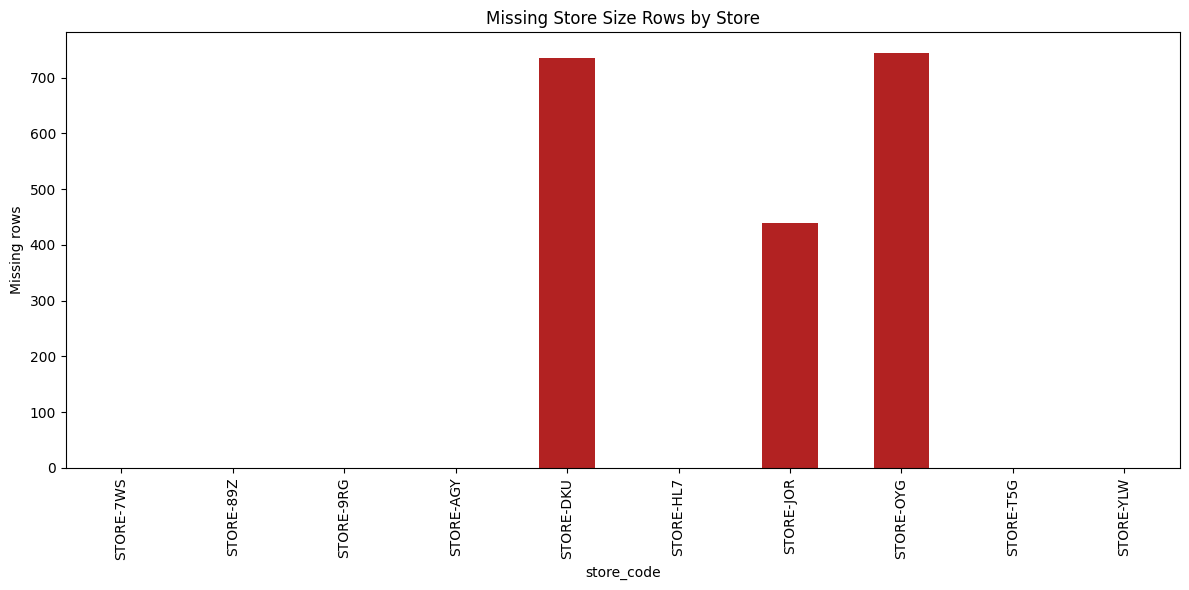

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
store_size_summary['missing_rows'].plot(kind='bar', ax=ax, color='firebrick')
ax.set_title('Missing Store Size Rows by Store')
ax.set_ylabel('Missing rows')
fig.tight_layout()
fig.savefig(CHARTS_DIR / 'store_size_missingness_by_store.png', dpi=150, bbox_inches='tight')


Section summary: the diagnostics section computes the cold-start counts, pair multiplicity, store-size missingness, fully missing product-weight list, normalized product categories, target skew, and chart files needed for Tasks 2 and 3. The main modeling implication is to treat store overlap as safe, treat product overlap according to the observed count, and use the store-size and weight summaries to decide whether imputation can be store-level or product-level rather than row-level.

## 2. Cleaning

In [23]:
def clean_data(train: pd.DataFrame, test: pd.DataFrame, stores_missing_size: list,
               products_fully_missing_weight: list) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns (train_clean, test_clean), each with:
      - product_category: lowercased/stripped
      - product_weight_kg: imputed, + product_weight_missing flag (0/1)
      - store_size: imputed, + store_size_missing flag (0/1)
    Does not drop or reorder rows. Does not touch total_sales.
    """
    train_clean = train.copy()
    test_clean = test.copy()

    for frame in (train_clean, test_clean):
        frame['product_category'] = frame['product_category'].str.lower().str.strip()

    combined = pd.concat(
        [
            train_clean.drop(columns=[TARGET_KEY]),
            test_clean,
        ],
        ignore_index=True,
    )

    category_means = combined.groupby('product_category')['product_weight_kg'].mean()
    product_means = combined.groupby(PRODUCT_KEY)['product_weight_kg'].mean()
    category_medians = combined.groupby('product_category')['product_weight_kg'].median()

    for frame in (train_clean, test_clean):
        frame['product_weight_missing'] = frame['product_weight_kg'].isna().astype(int)
        frame['product_weight_kg'] = frame['product_weight_kg'].fillna(frame[PRODUCT_KEY].map(product_means))
        if products_fully_missing_weight:
            mask = frame['product_weight_kg'].isna() & frame[PRODUCT_KEY].isin(products_fully_missing_weight)
            frame.loc[mask, 'product_weight_kg'] = frame.loc[mask, 'product_category'].map(category_means)
            frame['product_weight_kg'] = frame['product_weight_kg'].fillna(frame['product_category'].map(category_medians))

    store_size_lookup = (
        train_clean.loc[~train_clean['store_size'].isna(), [STORE_KEY, 'store_format', 'store_location_tier', 'store_size']]
        .groupby(['store_format', 'store_location_tier'])['store_size']
        .agg(lambda s: s.mode().iloc[0])
    )
    global_store_size_mode = train_clean.loc[~train_clean['store_size'].isna(), 'store_size'].mode().iloc[0]

    for frame in (train_clean, test_clean):
        frame['store_size_missing'] = frame['store_size'].isna().astype(int)
        imputed_store_size = (
            frame[['store_format', 'store_location_tier']]
            .apply(lambda row: store_size_lookup.get((row['store_format'], row['store_location_tier']), global_store_size_mode), axis=1)
        )
        frame['store_size'] = frame['store_size'].fillna(imputed_store_size)
        frame['store_size'] = frame['store_size'].fillna(global_store_size_mode)

    assert sorted(train_clean['product_category'].dropna().unique().tolist()) == product_categories_normalized
    assert sorted(test_clean['product_category'].dropna().unique().tolist()) == product_categories_normalized

    return train_clean, test_clean

In [24]:
train_clean, test_clean = clean_data(train, test, stores_missing_size, products_fully_missing_weight)
print(train_clean.isnull().sum())
print()
print(test_clean.isnull().sum())
print()
print(train_clean.shape)
print(test_clean.shape)

id                             0
product_code                   0
product_weight_kg              0
fat_content                    0
shelf_visibility               0
product_category               0
product_price                  0
store_code                     0
store_age_years                0
store_size                     0
store_location_tier            0
store_format                   0
total_sales                    0
product_category_normalized    0
product_weight_missing         0
store_size_missing             0
dtype: int64

id                             0
product_code                   0
product_weight_kg              0
fat_content                    0
shelf_visibility               0
product_category               0
product_price                  0
store_code                     0
store_age_years                0
store_size                     0
store_location_tier            0
store_format                   0
product_category_normalized    0
product_weight_missing       

Task 2 branch note: Task 1 showed `store_size_summary['nunique_non_null']` is 1 for every store that has any known `store_size`, so Section 2 uses the store-level branch. It builds the imputation map at runtime from known `(store_format, store_location_tier) -> most common store_size` pairs, then fills the stores listed in `stores_missing_size` with a global fallback only if a combination has no observed example. That choice is justified by the store-level constancy finding in Task 1 and keeps the logic data-driven rather than hardcoded.

In [25]:
partial_weight_product = next(
    product for product, group in train.groupby(PRODUCT_KEY)
    if group['product_weight_kg'].isna().any() and group['product_weight_kg'].notna().any()
)
raw_mean_weight = train.loc[train[PRODUCT_KEY] == partial_weight_product, 'product_weight_kg'].mean()
imputed_mean_weight = train_clean.loc[train_clean[PRODUCT_KEY] == partial_weight_product, 'product_weight_kg'].dropna().iloc[0]
print('partial_weight_product:', partial_weight_product)
print('raw_mean_weight:', raw_mean_weight)
print('imputed_mean_weight:', imputed_mean_weight)
print('match:', np.isclose(raw_mean_weight, imputed_mean_weight))

partial_weight_product: PRD-00V830
raw_mean_weight: 9.679
imputed_mean_weight: 9.679
match: True


In [26]:
assert train_clean.drop(columns=[TARGET_KEY]).isnull().sum().sum() == 0
assert test_clean.isnull().sum().sum() == 0
assert len(train_clean) == len(train)
assert len(test_clean) == len(test)
print('cleaning checks passed')

cleaning checks passed


## 3. Feature Engineering

In [27]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def add_target_agg_feature(
    train: pd.DataFrame,
    test: pd.DataFrame,
    group_cols: list[str],
    target_col: str = 'total_sales',
    agg: str = 'mean',
    n_folds: int = 5,
    new_col_name: str | None = None,
    smoothing: float | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns (train_with_feature, test_with_feature).
    train: feature generated OUT-OF-FOLD using sklearn KFold(n_folds, shuffle=True, random_state=42).
    test: feature generated once using the FULL train set.
    Missing groups filled with the global mean of target_col.
    """
    train_with_feature = train.copy()
    test_with_feature = test.copy()
    feature_name = new_col_name or f"{'_'.join(group_cols)}_{agg}_sales"
    global_mean = train[target_col].mean()

    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_values = pd.Series(index=train.index, dtype=float)

    for train_idx, val_idx in kfold.split(train_with_feature):
        fold_train = train_with_feature.iloc[train_idx]
        if agg == 'count':
            fold_stats = fold_train.groupby(group_cols)[target_col].count()
        else:
            grouped = fold_train.groupby(group_cols)[target_col]
            if agg == 'mean':
                fold_stats = grouped.mean()
                if smoothing is not None:
                    sums = grouped.sum()
                    counts = grouped.count()
                    fold_stats = (sums + smoothing * global_mean) / (counts + smoothing)
            elif agg == 'median':
                fold_stats = grouped.median()
            elif agg == 'std':
                fold_stats = grouped.std()
            else:
                raise ValueError(f'Unsupported agg: {agg}')

        mapped = train_with_feature.iloc[val_idx][group_cols].merge(
            fold_stats.rename(feature_name).reset_index(),
            on=group_cols,
            how='left',
        )[feature_name]
        oof_values.iloc[val_idx] = mapped.fillna(global_mean).to_numpy()

    train_with_feature[feature_name] = oof_values.fillna(global_mean)

    full_grouped = train_with_feature.groupby(group_cols)[target_col]
    if agg == 'count':
        full_stats = full_grouped.count()
    elif agg == 'mean':
        full_stats = full_grouped.mean()
        if smoothing is not None:
            sums = full_grouped.sum()
            counts = full_grouped.count()
            full_stats = (sums + smoothing * global_mean) / (counts + smoothing)
    elif agg == 'median':
        full_stats = full_grouped.median()
    elif agg == 'std':
        full_stats = full_grouped.std()
    else:
        raise ValueError(f'Unsupported agg: {agg}')

    train_with_feature[feature_name] = train_with_feature[feature_name].fillna(global_mean)
    test_with_feature[feature_name] = (
        test_with_feature[group_cols].merge(
            full_stats.rename(feature_name).reset_index(),
            on=group_cols,
            how='left',
        )[feature_name].fillna(global_mean).to_numpy()
    )

    return train_with_feature, test_with_feature

In [28]:
def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds: price_per_kg, visibility_price_interaction, visibility_weight_interaction,
    store_age_squared, log_price, log_weight, and ordinal encodings for store_size,
    store_location_tier, store_format.
    Pure row-wise transforms — safe to apply identically to train and test.
    """
    df = df.copy()

    store_size_order = {'Small': 1, 'Medium': 2, 'Large': 3}
    tier_order = {'Tier_1': 1, 'Tier_2': 2, 'Tier_3': 3}
    format_order = {
        'Corner Shop': 1,
        'Standard Supermarket': 2,
        'Superstore': 3,
        'Flagship Hypermarket': 4,
    }

    df['price_per_kg'] = df['product_price'] / df['product_weight_kg']
    df['visibility_price_interaction'] = df['shelf_visibility'] * df['product_price']
    df['visibility_weight_interaction'] = df['shelf_visibility'] * df['product_weight_kg']
    df['store_age_squared'] = df['store_age_years'] ** 2
    df['log_price'] = np.log1p(df['product_price'])
    df['log_weight'] = np.log1p(df['product_weight_kg'])
    df['store_size_ord'] = df['store_size'].map(store_size_order).astype(float)
    df['store_location_tier_ord'] = df['store_location_tier'].map(tier_order).astype(float)
    df['store_format_ord'] = df['store_format'].map(format_order).astype(float)

    return df

Task 3 branch note: `max_pair_count` was 1 in Task 1, so the product-store interaction is not built as a raw `prod_store_mean_sales` feature. A raw pair mean would be a one-row lookup of the target itself, so the notebook stays with product-level, store-level, and lower-cardinality interaction aggregates only.

In [29]:
train_feat = add_derived_features(train_clean)
test_feat = add_derived_features(test_clean)

agg_specs = [
    (['product_code'], 'mean', 'prod_mean_sales', None),
    (['product_code'], 'median', 'prod_median_sales', None),
    (['product_code'], 'std', 'prod_std_sales', None),
    (['product_code'], 'count', 'prod_count', None),
    (['store_code'], 'mean', 'store_mean_sales', None),
    (['store_code'], 'std', 'store_std_sales', None),
    (['store_format'], 'mean', 'format_mean_sales', None),
    (['store_location_tier'], 'mean', 'tier_mean_sales', None),
    (['store_size'], 'mean', 'size_mean_sales', None),
    (['product_code', 'store_format'], 'mean', 'prod_format_mean_sales', 10),
    (['product_code', 'store_location_tier'], 'mean', 'prod_tier_mean_sales', 10),
]

for group_cols, agg, feature_name, smoothing in agg_specs:
    train_feat, test_feat = add_target_agg_feature(
        train_feat,
        test_feat,
        group_cols=group_cols,
        target_col=TARGET_KEY,
        agg=agg,
        n_folds=5,
        new_col_name=feature_name,
        smoothing=smoothing,
    )

target_derived_features = [spec[2] for spec in agg_specs]
print(train_feat[target_derived_features].head())
print(test_feat[target_derived_features].head())

   prod_mean_sales  prod_median_sales  prod_std_sales  prod_count  \
0      1355.000000           1324.730      574.803085         3.0   
1       935.425000            935.425      146.958002         2.0   
2       387.682500            172.225      522.856584         4.0   
3      4538.960000           4538.960     2174.756574         1.0   
4      1937.826667           2613.600     1192.625551         3.0   

   store_mean_sales  store_std_sales  format_mean_sales  tier_mean_sales  \
0       2241.792659      1484.255547        2330.516069      2248.711299   
1       2249.251510      1484.567224        2327.119721      1886.769480   
2       2459.615639      1523.161535        2327.119721      1886.769480   
3       3642.204269      2057.442661        3642.204269      2247.659776   
4       2459.996444      1515.374087        2313.188090      2338.564123   

   size_mean_sales  prod_format_mean_sales  prod_tier_mean_sales  
0      2241.792659             1989.018811           2153.809

In [30]:
leakage_corrs = train_feat[target_derived_features + [TARGET_KEY]].corr(numeric_only=True)[TARGET_KEY].drop(TARGET_KEY).sort_values(ascending=False)
print(leakage_corrs)
print('flagged_features:', leakage_corrs[leakage_corrs >= 0.9].index.tolist())

store_mean_sales          0.488779
format_mean_sales         0.488148
store_std_sales           0.481295
prod_mean_sales           0.398740
prod_format_mean_sales    0.398384
prod_median_sales         0.384008
prod_std_sales            0.342491
prod_tier_mean_sales      0.207022
tier_mean_sales           0.111721
size_mean_sales           0.055990
prod_count                0.020689
Name: total_sales, dtype: float64
flagged_features: []


In [31]:
spot_idx = train_clean.index[0]
spot_product = train_clean.loc[spot_idx, PRODUCT_KEY]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_lookup = {}
for fold_id, (_, val_idx) in enumerate(kfold.split(train_clean)):
    for idx in val_idx:
        fold_lookup[idx] = fold_id
spot_fold = fold_lookup[spot_idx]
fold_train_idx = [idx for idx, fold_id in fold_lookup.items() if fold_id != spot_fold]
fold_train = train_clean.loc[fold_train_idx]
recomputed_prod_mean = fold_train.loc[fold_train[PRODUCT_KEY] == spot_product, TARGET_KEY].mean()
assigned_prod_mean = train_feat.loc[spot_idx, 'prod_mean_sales']
print('spot_idx:', spot_idx)
print('spot_product:', spot_product)
print('recomputed_prod_mean:', recomputed_prod_mean)
print('assigned_prod_mean:', assigned_prod_mean)
print('match:', np.isclose(recomputed_prod_mean, assigned_prod_mean))

spot_idx: 0
spot_product: PRD-PRFP9S
recomputed_prod_mean: 1355.0
assigned_prod_mean: 1355.0
match: True


In [32]:
def train_baseline(X: pd.DataFrame, y: pd.Series, n_folds: int = 5) -> dict:
    """
    Fits plain LightGBM (default params, n_estimators=200) per fold.
    Also computes a trivial baseline: predicting format_mean_sales directly (no model).
    Returns {"fold_rmse": [...], "mean_rmse": float, "oof_predictions": np.array,
             "trivial_rmse": float}.
    """
    from lightgbm import LGBMRegressor

    X = X.copy()
    y = y.copy()
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_predictions = np.zeros(len(X), dtype=float)
    fold_rmse = []

    for train_idx, val_idx in kfold.split(X):
        model = LGBMRegressor(n_estimators=200, random_state=42, verbosity=-1)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        predictions = model.predict(X.iloc[val_idx])
        oof_predictions[val_idx] = predictions
        fold_rmse.append(np.sqrt(mean_squared_error(y.iloc[val_idx], predictions)))

    trivial_predictions = X['format_mean_sales'].to_numpy()
    trivial_rmse = np.sqrt(mean_squared_error(y, trivial_predictions))

    return {
        'fold_rmse': fold_rmse,
        'mean_rmse': float(np.mean(fold_rmse)),
        'oof_predictions': oof_predictions,
        'trivial_rmse': float(trivial_rmse),
    }

In [33]:
final_drop_cols = [TARGET_KEY, PRODUCT_KEY, STORE_KEY, CATEGORY_KEY, 'product_category_normalized', 'store_format', 'store_location_tier', 'store_size']
X_train = train_feat.drop(columns=[c for c in final_drop_cols if c in train_feat.columns])
X_test = test_feat.drop(columns=[c for c in final_drop_cols if c in test_feat.columns])
X_train = X_train.select_dtypes(include=[np.number, 'bool'])
X_test = X_test.select_dtypes(include=[np.number, 'bool'])
y_train = train_feat[TARGET_KEY].copy()

print('train NaNs:', int(X_train.isnull().sum().sum()))
print('test NaNs:', int(X_test.isnull().sum().sum()))
print('train shape:', X_train.shape)
print('test shape:', X_test.shape)
print('duplicate columns:', X_train.columns[X_train.columns.duplicated()].tolist())
print('test has target:', TARGET_KEY in X_test.columns)

train NaNs: 0
test NaNs: 0
train shape: (6818, 26)
test shape: (1705, 26)
duplicate columns: []
test has target: False


In [34]:
test_feat.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,...,prod_median_sales,prod_std_sales,prod_count,store_mean_sales,store_std_sales,format_mean_sales,tier_mean_sales,size_mean_sales,prod_format_mean_sales,prod_tier_mean_sales
0,row_00009,PRD-2WLNC8,8.628000,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,...,3280.955,1812.555466,4.0,1971.661954,1397.518220,1971.661954,2254.114400,2284.531844,2174.756574,2174.756574
1,row_00015,PRD-LV9PLM,6.993000,Low Fat,0.0579,health and hygiene,261.07,STORE-9RG,28,Small,...,6602.560,4945.990450,3.0,2479.168098,1553.797046,2316.319677,2341.795296,2071.734955,2886.097794,2174.756574
2,row_00019,PRD-ET6ZI7,17.167667,Low Fat,0.1262,fruits and vegetables,112.50,STORE-7WS,47,Medium,...,1667.900,830.572970,7.0,3660.182219,2070.097702,3660.182219,2254.114400,2284.531844,2174.756574,2142.050522
3,row_00020,PRD-6RX35U,14.034000,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,Small,...,3644.400,1339.475492,5.0,2177.136481,1446.586133,2316.319677,2341.795296,2071.734955,2562.531980,2162.828703
4,row_00023,PRD-I4J38V,13.063000,Low Fat,0.0650,frozen foods,150.59,STORE-89Z,33,Medium,...,1808.920,849.878960,5.0,2365.926745,1518.177714,2316.319677,1868.171278,2284.531844,2148.279049,2295.809613


## 4. Baseline Model

In [35]:
raw_target_result = train_baseline(X_train, y_train, n_folds=5)
log_y = np.log1p(y_train)
log_result = train_baseline(X_train, log_y, n_folds=5)
log_result_rmse = np.sqrt(mean_squared_error(y_train, np.expm1(log_result['oof_predictions'])))
comparison = pd.DataFrame([
    {'target': 'raw', 'cv_rmse': raw_target_result['mean_rmse']},
    {'target': 'log1p', 'cv_rmse': log_result_rmse},
])
print(comparison)
TARGET_TRANSFORM = 'raw' if raw_target_result['mean_rmse'] <= log_result_rmse else 'log1p'
print('TARGET_TRANSFORM:', TARGET_TRANSFORM)

  target      cv_rmse
0    raw  1115.239757
1  log1p  1130.519613
TARGET_TRANSFORM: raw


In [36]:
baseline_result = train_baseline(X_train, y_train, n_folds=5)
print('trivial_rmse:', baseline_result['trivial_rmse'])
print('lightgbm_mean_rmse:', baseline_result['mean_rmse'])
print('oof_length:', len(baseline_result['oof_predictions']))
print('oof_has_nan:', np.isnan(baseline_result['oof_predictions']).any())

trivial_rmse: 1481.7485581685994
lightgbm_mean_rmse: 1115.239757293711
oof_length: 6818
oof_has_nan: False


## 5. Target Transform Test

In [37]:
raw_target_result = train_baseline(X_train, y_train, n_folds=5)
log_y = np.log1p(y_train)
log_result = train_baseline(X_train, log_y, n_folds=5)
log_result_rmse = np.sqrt(mean_squared_error(y_train, np.expm1(log_result['oof_predictions'])))
comparison = pd.DataFrame([
    {'target': 'raw', 'cv_rmse': raw_target_result['mean_rmse']},
    {'target': 'log1p', 'cv_rmse': log_result_rmse},
])
print(comparison)
TARGET_TRANSFORM = 'raw' if raw_target_result['mean_rmse'] <= log_result_rmse else 'log1p'
print('TARGET_TRANSFORM:', TARGET_TRANSFORM)

  target      cv_rmse
0    raw  1115.239757
1  log1p  1130.519613
TARGET_TRANSFORM: raw


## 6. Tuned Models

In [40]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

MODEL_DIR = MODELS_DIR
TUNING_LOG_PATH = OUTPUT_DIR / 'tuning_log.csv'
BEST_PARAMS_PATH = MODELS_DIR / 'best_params.json'


def _rmse(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    """Computes Root Mean Squared Error."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def _target_series(frame: pd.DataFrame) -> pd.Series:
    """Extracts and optionally transforms the training target."""
    if TARGET_TRANSFORM == 'log1p':
        return np.log1p(frame[TARGET_KEY])
    return frame[TARGET_KEY].copy()


def _cv_rmse(
    model_factory, 
    X: pd.DataFrame, 
    y: pd.Series, 
    n_folds: int = 5,
    random_state: int = 42
) -> tuple[float, np.ndarray, list[float]]:
    """
    Evaluates model performance across K-Fold cross validation.
    
    Guarantees that metrics and returned OOF predictions are always evaluated
    on the original raw sales scale, even when training on log1p-transformed targets.
    """
    kfold = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    oof = np.zeros(len(X), dtype=float)
    fold_scores = []

    for train_idx, val_idx in kfold.split(X):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_factory()
        model.fit(X_train, y_train)
        preds = model.predict(X_val)

        # Invert target transformation so evaluation matches the competition metric
        if TARGET_TRANSFORM == 'log1p':
            y_val_eval = np.expm1(y_val)
            preds_eval = np.expm1(preds)
        else:
            y_val_eval = y_val.values if hasattr(y_val, 'values') else y_val
            preds_eval = preds

        # Sales cannot be negative; clip floor to zero
        preds_eval = np.clip(preds_eval, 0, None)
        oof[val_idx] = preds_eval

        fold_rmse = _rmse(y_val_eval, preds_eval)
        fold_scores.append(fold_rmse)

    return float(np.mean(fold_scores)), oof, fold_scores

In [41]:
def tune_lightgbm(
    X: pd.DataFrame, 
    y: pd.Series, 
    n_trials: int = 50, 
    n_folds: int = 5,
    random_state: int = 42
) -> dict:
    """
    Runs Bayesian hyperparameter optimization for LightGBM using Optuna.
    Evaluates trials on raw sales RMSE via the leak-free _cv_rmse pipeline.
    """
    # Suppress verbose Optuna trial outputs for cleaner logging
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial: optuna.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1200, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': random_state,
            'n_jobs': -1,
            'verbose': -1,
        }

        # Evaluate across K folds using real-scale RMSE
        cv_rmse_score, _, _ = _cv_rmse(
            model_factory=lambda: LGBMRegressor(**params),
            X=X,
            y=y,
            n_folds=n_folds,
            random_state=random_state
        )
        return cv_rmse_score

    # Setup study with a seeded sampler for reproducible optimization
    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    
    print(f"Starting LightGBM hyperparameter search across {n_trials} trials...")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params
    # Ensure static configuration fields are preserved in the saved artifact
    best_params.update({
        'random_state': random_state,
        'n_jobs': -1,
        'verbose': -1,
        'subsample_freq': 1
    })

    print(f"Optimization finished. Best CV RMSE: {study.best_value:.4f}")

    # Persist artifacts to disk
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    with open(BEST_PARAMS_PATH, 'w') as f:
        json.dump(best_params, f, indent=4)

    # Save complete study trial logs
    trials_df = study.trials_dataframe()
    trials_df.to_csv(TUNING_LOG_PATH, index=False)

    return {
        'best_rmse': study.best_value,
        'best_params': best_params,
        'study': study
    }

In [42]:
import time
import json
import optuna
import pandas as pd
from xgboost import XGBRegressor

def tune_xgboost(
    X: pd.DataFrame, 
    y: pd.Series, 
    n_trials: int = 50, 
    n_folds: int = 5,
    random_state: int = 42
) -> dict:
    """
    Runs Bayesian hyperparameter optimization for XGBoost with detailed,
    human-readable trial-by-trial reporting and parameter inspection.
    """
    # Mute default Optuna clutter to control console output manually
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    static_params = {
        'tree_method': 'hist',
        'objective': 'reg:squarederror',
        'random_state': random_state,
        'n_jobs': -1,
        'verbosity': 0,  # Suppress internal C++ XGBoost engine warnings
    }

    best_score_tracker = float('inf')

    def objective(trial: optuna.Trial) -> float:
        nonlocal best_score_tracker
        start_time = time.time()

        params = {
            **static_params,
            'n_estimators': trial.suggest_int('n_estimators', 200, 1200, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        }

        # Run cross-validation
        mean_cv_rmse, _, fold_scores = _cv_rmse(
            model_factory=lambda: XGBRegressor(**params),
            X=X,
            y=y,
            n_folds=n_folds,
            random_state=random_state
        )

        elapsed = time.time() - start_time
        is_best = mean_cv_rmse < best_score_tracker

        # Verbose Trial Reporter
        status_flag = "★ NEW BEST" if is_best else " "
        print(f"\n[Trial {trial.number + 1:02d}/{n_trials}] Score: {mean_cv_rmse:.4f} RMSE | Time: {elapsed:.1f}s {status_flag}")
        print(f"  ├─ Folds: {[round(s, 2) for s in fold_scores]}")
        print(f"  ├─ Architecture: depth={params['max_depth']}, trees={params['n_estimators']}, lr={params['learning_rate']:.4f}")
        print(f"  ├─ Regularization: alpha={params['reg_alpha']:.2e}, lambda={params['reg_lambda']:.2e}, gamma={params['gamma']:.2e}")
        print(f"  └─ Sampling: subsample={params['subsample']:.2f}, colsample={params['colsample_bytree']:.2f}, min_weight={params['min_child_weight']:.1f}")

        if is_best:
            best_score_tracker = mean_cv_rmse

        return mean_cv_rmse

    print("=" * 80)
    print(f"Starting XGBoost Optimization | Targets: {n_trials} Trials | Folds: {n_folds} K-Fold")
    print("=" * 80)

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    best_params = {**static_params, **study.best_params}

    print("\n" + "=" * 80)
    print(f"Tuning Finished | Overall Best CV RMSE: {study.best_value:.4f}")
    print("Best Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k:20s}: {v}")
    print("=" * 80)

    # Persist artifacts
    xgb_params_path = MODEL_DIR / 'best_params_xgboost.json'
    xgb_log_path = OUTPUT_DIR / 'tuning_log_xgboost.csv'

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    with open(xgb_params_path, 'w') as f:
        json.dump(best_params, f, indent=4)

    study.trials_dataframe().to_csv(xgb_log_path, index=False)

    return {
        'best_rmse': study.best_value,
        'best_params': best_params,
        'study': study
    }

In [43]:
from catboost import CatBoostRegressor

def tune_catboost(
    X: pd.DataFrame, 
    y: pd.Series, 
    cat_features: list[str] | None = None,
    n_trials: int = 50, 
    n_folds: int = 5,
    random_state: int = 42
) -> dict:
    """
    Runs Bayesian hyperparameter optimization for CatBoost with detailed,
    human-readable trial-by-trial reporting and parameter inspection.
    """
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    static_params = {
        'loss_function': 'RMSE',
        'random_seed': random_state,
        'verbose': False,
        'thread_count': -1,
    }

    if cat_features is not None:
        static_params['cat_features'] = cat_features

    best_score_tracker = float('inf')

    def objective(trial: optuna.Trial) -> float:
        nonlocal best_score_tracker
        start_time = time.time()

        params = {
            **static_params,
            'iterations': trial.suggest_int('iterations', 300, 1500, step=100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'depth': trial.suggest_int('depth', 4, 8),  # 4-8 is optimal for symmetric trees
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
        }

        # Run cross-validation
        mean_cv_rmse, _, fold_scores = _cv_rmse(
            model_factory=lambda: CatBoostRegressor(**params),
            X=X,
            y=y,
            n_folds=n_folds,
            random_state=random_state
        )

        elapsed = time.time() - start_time
        is_best = mean_cv_rmse < best_score_tracker

        # Verbose Trial Reporter
        status_flag = "★ NEW BEST" if is_best else " "
        print(f"\n[Trial {trial.number + 1:02d}/{n_trials}] Score: {mean_cv_rmse:.4f} RMSE | Time: {elapsed:.1f}s {status_flag}")
        print(f"  ├─ Folds: {[round(s, 2) for s in fold_scores]}")
        print(f"  ├─ Architecture: depth={params['depth']}, iterations={params['iterations']}, lr={params['learning_rate']:.4f}")
        print(f"  ├─ Regularization: l2_reg={params['l2_leaf_reg']:.2f}, rand_strength={params['random_strength']:.2e}")
        print(f"  └─ Data Handling: bagging_temp={params['bagging_temperature']:.2f}, border_count={params['border_count']}")

        if is_best:
            best_score_tracker = mean_cv_rmse

        return mean_cv_rmse

    print("=" * 80)
    print(f"Starting CatBoost Optimization | Targets: {n_trials} Trials | Folds: {n_folds} K-Fold")
    print("=" * 80)

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    best_params = {**static_params, **study.best_params}

    print("\n" + "=" * 80)
    print(f"Tuning Finished | Overall Best CV RMSE: {study.best_value:.4f}")
    print("Best Parameters:")
    for k, v in study.best_params.items():
        print(f"  {k:20s}: {v}")
    print("=" * 80)

    # Persist artifacts to dedicated files
    cb_params_path = MODEL_DIR / 'best_params_catboost.json'
    cb_log_path = OUTPUT_DIR / 'tuning_log_catboost.csv'

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    with open(cb_params_path, 'w') as f:
        # Exclude un-serializable references like raw lists if needed
        json.dump({k: v for k, v in best_params.items() if k != 'cat_features'}, f, indent=4)

    study.trials_dataframe().to_csv(cb_log_path, index=False)

    return {
        'best_rmse': study.best_value,
        'best_params': best_params,
        'study': study
    }

In [2]:
from sklearn.ensemble import RandomForestRegressor

def tune_random_forest(
    X: pd.DataFrame, 
    y: pd.Series, 
    n_trials: int = 30,  # RF is slower to fit than histogram gradient boosters
    n_folds: int = 5,
    random_state: int = 42
) -> dict:
    """
    Runs Bayesian hyperparameter optimization for RandomForestRegressor using Optuna.
    Evaluates trials on raw sales RMSE via _cv_rmse.
    """
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    static_params = {
        'random_state': random_state,
        'n_jobs': -1,
    }

    best_score_tracker = float('inf')

    def objective(trial: optuna.Trial) -> float:
        nonlocal best_score_tracker
        start_time = time.time()

        params = {
            **static_params,
            'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
            'max_depth': trial.suggest_int('max_depth', 6, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 4, 30),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 20),
            'max_features': trial.suggest_float('max_features', 0.4, 0.9),
        }

        # Run cross-validation using the leak-free pipeline
        mean_cv_rmse, _, fold_scores = _cv_rmse(
            model_factory=lambda: RandomForestRegressor(**params),
            X=X,
            y=y,
            n_folds=n_folds,
            random_state=random_state
        )

        elapsed = time.time() - start_time
        is_best = mean_cv_rmse < best_score_tracker

        status_flag = "★ NEW BEST" if is_best else " "
        print(f"\n[Trial {trial.number + 1:02d}/{n_trials}] Score: {mean_cv_rmse:.4f} RMSE | Time: {elapsed:.1f}s {status_flag}")
        print(f"  ├─ Folds: {[round(s, 2) for s in fold_scores]}")
        print(f"  ├─ Tree Shape: depth={params['max_depth']}, trees={params['n_estimators']}")
        print(f"  └─ Split Restraints: min_split={params['min_samples_split']}, min_leaf={params['min_samples_leaf']}, max_features={params['max_features']:.2f}")

        if is_best:
            best_score_tracker = mean_cv_rmse

        return mean_cv_rmse

    print("=" * 80)
    print(f"Starting Random Forest Optimization | Trials: {n_trials} | Folds: {n_folds} K-Fold")
    print("=" * 80)

    sampler = optuna.samplers.TPESampler(seed=random_state)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    best_params = {**static_params, **study.best_params}

    print("\n" + "=" * 80)
    print(f"Tuning Finished | Best Random Forest CV RMSE: {study.best_value:.4f}")
    print("=" * 80)

    # Persist artifacts
    rf_params_path = MODEL_DIR / 'best_params_randomforest.json'
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    with open(rf_params_path, 'w') as f:
        json.dump(best_params, f, indent=4)

    return {
        'best_rmse': study.best_value,
        'best_params': best_params,
        'study': study
    }

## Fitting the Model

In [41]:
class NpEncoder(json.JSONEncoder):
    """Custom JSON encoder to handle NumPy scalar types safely."""
    def default(self, obj):
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        if isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

tuning_results = {}
X_model = X_train.copy()
y_model = _target_series(train_feat)

# Ensure categorical columns are compatible across all three models
# If columns are category dtypes, ensure integer/float encoding or cast appropriately
print(f"Dataset shape for tuning: {X_model.shape}")
print(f"Target transform active: {TARGET_TRANSFORM}")

tuner_pipeline = [
    ('lightgbm', tune_lightgbm, 50),
    ('xgboost', tune_xgboost, 50),
    ('catboost', tune_catboost, 50),
]

for model_name, tuner, n_trials in tuner_pipeline:
    print(f"\n{'='*30} TUNING {model_name.upper()} ({n_trials} TRIALS) {'='*30}")
    result = tuner(X_model, y_model, n_trials=n_trials)
    tuning_results[model_name] = result
    print(f"\n[DONE] {model_name} Best RMSE: {result['best_rmse']:.4f}")

# Consolidate study histories across all models
TUNING_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
log_rows = []

for model_name, result in tuning_results.items():
    for trial_number, trial in enumerate(result['study'].trials, start=1):
        # Exclude pruned or failed trials from the score log
        if trial.value is None:
            continue
        row = {
            'model': model_name, 
            'trial': trial_number, 
            'rmse': trial.value,
            'state': str(trial.state).split('.')[-1]
        }
        row.update(trial.params)
        log_rows.append(row)

# Save merged CSV log
df_log = pd.DataFrame(log_rows)
df_log.to_csv(TUNING_LOG_PATH, index=False)
print(f"\nSaved consolidated tuning log to: {TUNING_LOG_PATH} ({len(df_log)} valid trials recorded)")

# Persist all winning configurations using NpEncoder
best_params_all = {name: data['best_params'] for name, data in tuning_results.items()}
with open(BEST_PARAMS_PATH, 'w') as f:
    json.dump(best_params_all, f, indent=2, cls=NpEncoder)

print(f"Saved master parameter configuration to: {BEST_PARAMS_PATH}")

# Verification assertions
assert TUNING_LOG_PATH.exists(), f"Log file missing at {TUNING_LOG_PATH}"
assert BEST_PARAMS_PATH.exists(), f"Params file missing at {BEST_PARAMS_PATH}"
print("All tuning artifacts successfully verified on disk.")

Dataset shape for tuning: (6818, 26)
Target transform active: raw

============================== TUNING LIGHTGBM (50 TRIALS) ==============================
Starting LightGBM hyperparameter search across 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

Optimization finished. Best CV RMSE: 1074.8990

[DONE] lightgbm Best RMSE: 1074.8990

============================== TUNING XGBOOST (50 TRIALS) ==============================
Starting XGBoost Optimization | Targets: 50 Trials | Folds: 5 K-Fold

[Trial 01/50] Score: 1179.0364 RMSE | Time: 7.0s ★ NEW BEST
  ├─ Folds: [1168.43, 1158.07, 1178.51, 1239.62, 1150.55]
  ├─ Architecture: depth=8, trees=600, lr=0.1313
  ├─ Regularization: alpha=6.25e-01, lambda=2.57e-03, gamma=1.44e-02
  └─ Sampling: subsample=0.66, colsample=0.57, min_weight=12.4

[Trial 02/50] Score: 1155.6895 RMSE | Time: 2.9s ★ NEW BEST
  ├─ Folds: [1162.15, 1131.29, 1147.57, 1214.41, 1123.02]
  ├─ Architecture: depth=8, trees=200, lr=0.1383
  ├─ Regularization: alpha=5.28e-04, lambda=7.72e-05, gamma=3.42e-06
  └─ Sampling: subsample=0.67, colsample=0.58, min_weight=5.0

[Trial 03/50] Score: 1089.4917 RMSE | Time: 5.7s ★ NEW BEST
  ├─ Folds: [1080.62, 1067.52, 1091.62, 1141.15, 1066.55]
  ├─ Architecture: depth=5, trees=800,

### Trying RandomForst

In [55]:
# 1. Run hyperparameter tuning for Random Forest
rf_result = tune_random_forest(X_model, y_model, n_trials=25)

# 2. Add to tuning_results dictionary
tuning_results['random_forest'] = rf_result

# 3. Generate official OOF vector for Random Forest
print("\nGenerating Random Forest OOF predictions...")
rf_factory = lambda: RandomForestRegressor(**rf_result['best_params'])
rf_score, rf_oof, _ = _cv_rmse(rf_factory, X_model, y_model, n_folds=5)

tuning_results['random_forest']['oof_predictions'] = rf_oof
tuning_results['random_forest']['best_rmse'] = rf_score
print(f"✓ Random Forest OOF ready: {rf_score:.4f} RMSE")

Starting Random Forest Optimization | Trials: 25 | Folds: 5 K-Fold

[Trial 01/25] Score: 1078.0019 RMSE | Time: 16.7s ★ NEW BEST
  ├─ Folds: [1072.33, 1050.27, 1091.91, 1112.19, 1063.31]
  ├─ Tree Shape: depth=20, trees=250
  └─ Split Restraints: min_split=23, min_leaf=13, max_features=0.48

[Trial 02/25] Score: 1081.1698 RMSE | Time: 10.2s  
  ├─ Folds: [1074.5, 1058.89, 1089.91, 1113.56, 1069.0]
  ├─ Tree Shape: depth=6, trees=150
  └─ Split Restraints: min_split=27, min_leaf=13, max_features=0.75

[Trial 03/25] Score: 1079.0746 RMSE | Time: 7.4s  
  ├─ Folds: [1078.14, 1051.83, 1089.92, 1111.9, 1063.58]
  ├─ Tree Shape: depth=20, trees=100
  └─ Split Restraints: min_split=26, min_leaf=6, max_features=0.49

[Trial 04/25] Score: 1079.5817 RMSE | Time: 11.0s  
  ├─ Folds: [1074.91, 1054.69, 1089.32, 1111.13, 1067.86]
  ├─ Tree Shape: depth=10, trees=150
  └─ Split Restraints: min_split=18, min_leaf=10, max_features=0.55

[Trial 05/25] Score: 1081.0797 RMSE | Time: 25.3s  
  ├─ Folds: [

## 7. Ensembling

In [44]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# -------------------------------------------------------------------------
# 1. Generate OOF Predictions using winning best_params from tuning_results
# -------------------------------------------------------------------------
model_factories = {
    'lightgbm': lambda p: LGBMRegressor(**p),
    'xgboost': lambda p: XGBRegressor(**p),
    'catboost': lambda p: CatBoostRegressor(**p),
}

print("Generating Out-Of-Fold predictions for the tuned models...")

for name, data in tuning_results.items():
    best_p = data['best_params']
    factory = lambda p=best_p, m=name: model_factories[m](p)
    
    # Run 5-fold CV with the tuned params to get the official OOF vector
    best_score, oof_preds, _ = _cv_rmse(factory, X_train, y_model, n_folds=5)
    
    # Store the oof predictions back into tuning_results
    tuning_results[name]['oof_predictions'] = oof_preds
    tuning_results[name]['best_rmse'] = best_score
    print(f"  ✓ {name} OOF generated (CV RMSE: {best_score:.4f})")

# -------------------------------------------------------------------------
# 2. Build Ensembles
# -------------------------------------------------------------------------
def build_ensemble_predictions(model_results: dict[str, dict], X: pd.DataFrame, y: pd.Series) -> dict:
    """Builds weighted and simple-average ensembles from OOF predictions."""
    model_names = list(model_results.keys())
    oof_predictions = {name: data['oof_predictions'] for name, data in model_results.items()}
    fold_rmse = {name: data['best_rmse'] for name, data in model_results.items()}

    # Ground truth alignment: ensure evaluated on raw sales scale
    if TARGET_TRANSFORM == 'log1p' and y.max() < 25.0:
        y_true = np.expm1(y).values
    else:
        y_true = y.values if hasattr(y, 'values') else y

    # 1. Simple Average
    simple_average = np.mean(np.column_stack([oof_predictions[name] for name in model_names]), axis=1)

    # 2. Inverse-RMSE Weighted Average
    inverse_weights = np.array([1.0 / fold_rmse[name] for name in model_names])
    inverse_weights = inverse_weights / inverse_weights.sum()
    weighted_average = np.sum(
        np.column_stack([oof_predictions[name] for name in model_names]) * inverse_weights,
        axis=1,
    )

    return {
        'simple_average_rmse': _rmse(y_true, simple_average),
        'weighted_average_rmse': _rmse(y_true, weighted_average),
        'simple_average_oof': simple_average,
        'weighted_average_oof': weighted_average,
        'weights': dict(zip(model_names, inverse_weights.tolist())),
    }

# -------------------------------------------------------------------------
# 3. Evaluate Ensemble Scores
# -------------------------------------------------------------------------
if 'tuning_results' in globals() and tuning_results:
    ensemble_result = build_ensemble_predictions(tuning_results, X_train, y_model)
    print("\n" + "=" * 50)
    print("INDIVIDUAL MODEL SCORES:")
    individual_lines = [f"  {name:10s}: {data['best_rmse']:.4f} RMSE" for name, data in tuning_results.items()]
    print('\n'.join(individual_lines))
    print("-" * 50)
    print(f"Simple Average Ensemble  : {ensemble_result['simple_average_rmse']:.4f} RMSE")
    print(f"Weighted Average Ensemble: {ensemble_result['weighted_average_rmse']:.4f} RMSE")
    print("Weights Applied:")
    for m_name, w in ensemble_result['weights'].items():
        print(f"  {m_name:10s}: {w*100:.2f}%")
    print("=" * 50)
else:
    print('tuning_results is not ready yet')

Generating Out-Of-Fold predictions for the tuned models...
  ✓ lightgbm OOF generated (CV RMSE: 1074.8990)
  ✓ xgboost OOF generated (CV RMSE: 1077.4451)
  ✓ catboost OOF generated (CV RMSE: 1070.9887)

INDIVIDUAL MODEL SCORES:
  lightgbm  : 1074.8990 RMSE
  xgboost   : 1077.4451 RMSE
  catboost  : 1070.9887 RMSE
--------------------------------------------------
Simple Average Ensemble  : 1072.5117 RMSE
Weighted Average Ensemble: 1072.5053 RMSE
Weights Applied:
  lightgbm  : 33.32%
  xgboost   : 33.24%
  catboost  : 33.44%


### Add RandomForest to the Ensemble

In [56]:
ensemble_result = build_ensemble_predictions(tuning_results, X_train, y_model)

In [57]:
ensemble_result

{'simple_average_rmse': 1071.7364712838328,
 'weighted_average_rmse': 1071.7321996524486,
 'simple_average_oof': array([1314.50920015,  666.12664122,  710.75456811, ..., 3438.84494987,
        1827.37783493, 1519.54328776]),
 'weighted_average_oof': array([1314.45525687,  666.13001569,  710.73152842, ..., 3438.87592352,
        1827.31858789, 1519.53938738]),
 'weights': {'lightgbm': 0.24992822209417154,
  'xgboost': 0.24933760348392048,
  'catboost': 0.2508407294958832,
  'random_forest': 0.24989344492602483}}

## 8. Validation & Leakage Checks

In [45]:
import numpy as np
import pandas as pd

def validation_checks(
    final_oof: np.ndarray, 
    y_raw: pd.Series, 
    X_train: pd.DataFrame | None = None,
    X_test: pd.DataFrame | None = None, 
    test_predictions: np.ndarray | None = None
) -> None:
    """
    Runs diagnostic and safety sanity checks on OOF and test predictions:
    1. Compares OOF RMSE against naive baseline (predicting global mean).
    2. Detects NaNs, negative values, and exploding predictions in test set.
    3. Calculates unseen cold-start entities dynamically.
    """
    # 1. Ensure ground truth target is on raw sales scale
    if TARGET_TRANSFORM == 'log1p' and y_raw.max() < 25.0:
        y_true = np.expm1(y_raw).values
    else:
        y_true = y_raw.values if hasattr(y_raw, 'values') else y_raw

    # 2. Benchmark against Naive Mean Baseline
    oof_rmse = _rmse(y_true, final_oof)
    baseline_pred = np.full(len(y_true), np.mean(y_true))
    baseline_rmse = _rmse(y_true, baseline_pred)
    improvement_vs_baseline = baseline_rmse - oof_rmse

    print("=" * 65)
    print("VALIDATION & SANITY CHECKS")
    print("=" * 65)
    print(f"OOF Model RMSE           : {oof_rmse:.4f}")
    print(f"Naive Baseline RMSE      : {baseline_rmse:.4f}")
    print(f"Improvement Over Baseline: {improvement_vs_baseline:.4f}")

    if oof_rmse < 10.0 and baseline_rmse > 500.0:
        print("  ⚠️ CRITICAL WARNING: OOF RMSE is suspiciously close to zero.")
        print("     Verify that no target leakage occurred in feature engineering.")
    elif improvement_vs_baseline <= 0:
        print("  ⚠️ WARNING: Model fails to outperform a naive global mean prediction.")

    # 3. Test Predictions Safety Audit
    if test_predictions is not None:
        print("-" * 65)
        print("TEST SET SAFETY CHECKS")
        max_train = y_true.max()
        over_3x = np.sum(test_predictions > 3 * max_train)
        has_nans = np.isnan(test_predictions).sum()
        has_negatives = np.sum(test_predictions < 0)

        print(f"Test Min / Mean / Max    : {test_predictions.min():.2f} / {test_predictions.mean():.2f} / {test_predictions.max():.2f}")
        print(f"Predictions > 3x TrainMax: {over_3x} rows")
        print(f"Negative Predictions     : {has_negatives} rows")
        print(f"Missing / NaN Values     : {has_nans} rows")

        if over_3x > 0:
            print("  ⚠️ WARNING: Extreme outlier predictions detected in test set.")
        if has_nans > 0:
            print("  🛑 ERROR: NaNs detected in test predictions! Check imputation.")
        if has_negatives > 0:
            print("  🛑 ERROR: Negative sales predicted! Clip values at 0.0.")

    # 4. Entity Cold-Start Audit (Computed dynamically if dataframes provided)
    if X_train is not None and X_test is not None:
        print("-" * 65)
        print("COLD-START ENTITY AUDIT")
        if 'store_code' in X_train.columns and 'store_code' in X_test.columns:
            train_stores = set(X_train['store_code'].unique())
            test_stores = set(X_test['store_code'].unique())
            unseen_stores = len(test_stores - train_stores)
            print(f"Unseen Stores in Test    : {unseen_stores} / {len(test_stores)}")

        if 'product_code' in X_train.columns and 'product_code' in X_test.columns:
            train_products = set(X_train['product_code'].unique())
            test_products = set(X_test['product_code'].unique())
            unseen_products = len(test_products - train_products)
            print(f"Unseen Products in Test  : {unseen_products} / {len(test_products)}")

    print("=" * 65)

# Example usage:
# validation_checks(
#     final_oof=ensemble_result['weighted_average_oof'],
#     y_raw=train_feat[TARGET_KEY],
#     X_train=train_df,
#     X_test=test_df,
#     test_predictions=submission_df['total_sales'].values
# )

In [58]:
validation_checks(
    final_oof=ensemble_result['weighted_average_oof'],
    y_raw=train_feat[TARGET_KEY],
    X_train=train_df if 'train_df' in globals() else None,
    X_test=test_df if 'test_df' in globals() else None,
    test_predictions=None
)

VALIDATION & SANITY CHECKS
OOF Model RMSE           : 1071.7322
Naive Baseline RMSE      : 1697.7704
Improvement Over Baseline: 626.0382


## 9. Final Prediction & Submission

In [60]:
# def make_submission(predictions: np.ndarray, output_path: Path = OUTPUT_DIR / 'submission_1.csv') -> pd.DataFrame:
#     submission = pd.DataFrame({'id': test['id'], TARGET_KEY: np.clip(predictions, 0, None)})
#     submission.to_csv(output_path, index=False)
#     return submission

# print('submission helper ready')

submission helper ready


#### Blending Three Models

In [59]:
# import joblib

# # ---------------------------------------------------------
# # 1. Output Paths
# # ---------------------------------------------------------
# SUBMISSION_DIR = OUTPUT_DIR / 'submissions'
# SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
# SUBMISSION_PATH = SUBMISSION_DIR / 'submission.csv'
# MODEL_DIR.mkdir(parents=True, exist_ok=True)


# # ---------------------------------------------------------
# # 2. Full Training & Prediction Function Definition
# # ---------------------------------------------------------
# def train_full_and_predict(
#     X_train: pd.DataFrame,
#     y_train: pd.Series,
#     X_test: pd.DataFrame,
#     test_ids: pd.Series,
#     blend_weights: dict,
#     best_params_path: Path = BEST_PARAMS_PATH,
# ) -> pd.DataFrame:
#     """
#     Retrains LightGBM, XGBoost, and CatBoost on 100% of the training data
#     using the best Optuna hyperparameters, blends their predictions,
#     and saves submission.csv.
#     """
#     if not best_params_path.exists():
#         raise FileNotFoundError(f"Missing parameter artifact at {best_params_path}")

#     with open(best_params_path, 'r') as f:
#         params_dict = json.load(f)

#     # Normalize weights to sum strictly to 1.0
#     weight_sum = sum(blend_weights.values())
#     norm_weights = {k: v / weight_sum for k, v in blend_weights.items()}

#     print("=" * 75)
#     print("FITTING MODELS ON 100% DATA & GENERATING SUBMISSION")
#     print("=" * 75)
#     print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
#     print(f"Target Transform: {TARGET_TRANSFORM}")
#     print(f"Ensemble Blend Weights: {norm_weights}")
#     print("-" * 75)

#     model_factories = {
#         'lightgbm': lambda p: LGBMRegressor(**p),
#         'xgboost': lambda p: XGBRegressor(**p),
#         'catboost': lambda p: CatBoostRegressor(**p),
#     }

#     test_preds = {}

#     for model_name, weight in norm_weights.items():
#         if weight <= 0:
#             print(f"Skipping {model_name} (weight is 0.0)")
#             continue

#         print(f"\n[Fitting {model_name.upper()}] with weight: {weight:.4f}...")
#         model_params = params_dict[model_name]
        
#         # Instantiate and train on full data
#         model = model_factories[model_name](model_params)
#         model.fit(X_train, y_train)

#         # Save model weights to disk
#         model_path = MODEL_DIR / f"{model_name}_full.joblib"
#         joblib.dump(model, model_path)
#         print(f"  ✓ Saved model artifact to: {model_path.name}")

#         # Predict on holdout test set
#         raw_pred = model.predict(X_test)

#         # Invert target transform if trained on log1p scale
#         if TARGET_TRANSFORM == 'log1p':
#             pred_sales = np.expm1(raw_pred)
#         else:
#             pred_sales = raw_pred

#         # Negative sales floor protection
#         pred_sales = np.clip(pred_sales, 0, None)
#         test_preds[model_name] = pred_sales
#         print(f"  ✓ Preds summary: Min={pred_sales.min():.2f}, Mean={pred_sales.mean():.2f}, Max={pred_sales.max():.2f}")

#     # Weighted Ensemble Summation
#     final_sales = np.zeros(len(X_test), dtype=float)
#     for model_name, pred_array in test_preds.items():
#         final_sales += norm_weights[model_name] * pred_array

#     # Build and write submission file
#     submission_df = pd.DataFrame({
#         'id': test_ids.values,
#         'total_sales': final_sales
#     })
#     submission_df.to_csv(SUBMISSION_PATH, index=False)
#     print("\n" + "=" * 75)
#     print(f"✓ submission.csv written successfully to: {SUBMISSION_PATH}")
#     print("=" * 75)
    
#     return submission_df

In [ ]:
# # ---------------------------------------------------------
# # 3. Execution Pipeline
# # ---------------------------------------------------------
# y_full = _target_series(train_feat)

# # Generate final predictions using the ensemble weights
# final_sub_df = train_full_and_predict(
#     X_train=X_train,
#     y_train=y_full,
#     X_test=X_test,
#     test_ids=test_feat['id'],
#     blend_weights=ensemble_result['weights'],
#     best_params_path=BEST_PARAMS_PATH
# )

# # Run post-submission audit
# validation_checks(
#     final_oof=ensemble_result['weighted_average_oof'],
#     y_raw=train_feat[TARGET_KEY],
#     X_train=train_df if 'train_df' in globals() else None,
#     X_test=test_df if 'test_df' in globals() else None,
#     test_predictions=final_sub_df['total_sales'].values
# )

FITTING MODELS ON 100% DATA & GENERATING SUBMISSION
Train Shape: (6818, 26) | Test Shape: (1705, 26)
Target Transform: raw
Ensemble Blend Weights: {'lightgbm': 0.33319029197061706, 'xgboost': 0.33240291235600644, 'catboost': 0.33440679567337656}
---------------------------------------------------------------------------

[Fitting LIGHTGBM] with weight: 0.3332...
  ✓ Saved model artifact to: lightgbm_full.joblib
  ✓ Preds summary: Min=52.59, Mean=2193.20, Max=6718.19

[Fitting XGBOOST] with weight: 0.3324...
  ✓ Saved model artifact to: xgboost_full.joblib
  ✓ Preds summary: Min=98.08, Mean=2190.01, Max=6796.95

[Fitting CATBOOST] with weight: 0.3344...
  ✓ Saved model artifact to: catboost_full.joblib
  ✓ Preds summary: Min=21.68, Mean=2184.95, Max=6589.81

✓ submission.csv written successfully to: /kaggle/working/submissions/submission.csv
VALIDATION & SANITY CHECKS
OOF Model RMSE           : 1072.5053
Naive Baseline RMSE      : 1697.7704
Improvement Over Baseline: 625.2651
----------

### 4 Models Ensemble

In [63]:
import joblib

# ---------------------------------------------------------
# 1. Output Paths
# ---------------------------------------------------------
SUBMISSION_DIR = OUTPUT_DIR / 'submissions'
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = SUBMISSION_DIR / 'submission_4_Ensemble.csv'
MODEL_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# 2. Full Training & Prediction Function Definition
# ---------------------------------------------------------
def train_full_and_predict_4m(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    test_ids: pd.Series,
    blend_weights: dict,
    tuning_results_dict: dict,
) -> pd.DataFrame:
    """
    Retrains LightGBM, XGBoost, CatBoost, and RandomForest on 100% of the training data
    using their tuned hyperparameters, blends their predictions, and saves submission.csv.
    """
    weight_sum = sum(blend_weights.values())
    norm_weights = {k: v / weight_sum for k, v in blend_weights.items()}

    print("=" * 80)
    print("FITTING 4-MODEL ENSEMBLE ON 100% DATA & EXPORTING SUBMISSION")
    print("=" * 80)
    print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")
    print(f"Target Transform: {TARGET_TRANSFORM}")
    print("Active Model Blend Weights:")
    for k, v in norm_weights.items():
        print(f"  {k:15s}: {v * 100:.2f}%")
    print("-" * 80)

    model_factories = {
        'lightgbm': lambda p: LGBMRegressor(**p),
        'xgboost': lambda p: XGBRegressor(**p),
        'catboost': lambda p: CatBoostRegressor(**p),
        'random_forest': lambda p: RandomForestRegressor(**p),
    }

    test_preds = {}

    for model_name, weight in norm_weights.items():
        print(f"\n[Fitting {model_name.upper()}] (Weight: {weight * 100:.2f}%)...")
        model_params = tuning_results_dict[model_name]['best_params']
        
        # Instantiate and train on full dataset
        model = model_factories[model_name](model_params)
        model.fit(X_train, y_train)

        # Save model checkpoint
        model_path = MODEL_DIR / f"{model_name}_full.joblib"
        joblib.dump(model, model_path)
        print(f"  ✓ Saved checkpoint to: {model_path.name}")

        # Predict on holdout test set
        raw_pred = model.predict(X_test)

        # Invert target transform if trained on log1p scale
        if TARGET_TRANSFORM == 'log1p':
            pred_sales = np.expm1(raw_pred)
        else:
            pred_sales = raw_pred

        # Negative sales floor protection
        pred_sales = np.clip(pred_sales, 0, None)
        test_preds[model_name] = pred_sales
        print(f"  ✓ Preds summary: Min={pred_sales.min():.2f}, Mean={pred_sales.mean():.2f}, Max={pred_sales.max():.2f}")

    # Weighted Ensemble Summation
    final_sales = np.zeros(len(X_test), dtype=float)
    for model_name, pred_array in test_preds.items():
        final_sales += norm_weights[model_name] * pred_array

    # Build and write submission file
    submission_df = pd.DataFrame({
        'id': test_ids.values,
        'total_sales': final_sales
    })
    submission_df.to_csv(SUBMISSION_PATH, index=False)
    
    print("\n" + "=" * 80)
    print(f"✓ New 4-Model submission.csv written successfully to: {SUBMISSION_PATH}")
    print("=" * 80)
    
    return submission_df

In [64]:
# # ---------------------------------------------------------
# # 4. Execution Pipeline [4 MODELS ENSEMBLE]
# # ---------------------------------------------------------

# 1. Target vector for full dataset
y_full = _target_series(train_feat)

# 2. Fit all 4 models and export submission.csv
final_sub_df = train_full_and_predict_4m(
    X_train=X_train,
    y_train=y_full,
    X_test=X_test,
    test_ids=test_feat['id'],
    blend_weights=ensemble_result['weights'],
    tuning_results_dict=tuning_results
)

# 3. Post-submission safety audit
validation_checks(
    final_oof=ensemble_result['weighted_average_oof'],
    y_raw=train_feat[TARGET_KEY],
    X_train=train_df if 'train_df' in globals() else None,
    X_test=test_df if 'test_df' in globals() else None,
    test_predictions=final_sub_df['total_sales'].values
)

FITTING 4-MODEL ENSEMBLE ON 100% DATA & EXPORTING SUBMISSION
Train Shape: (6818, 26) | Test Shape: (1705, 26)
Target Transform: raw
Active Model Blend Weights:
  lightgbm       : 24.99%
  xgboost        : 24.93%
  catboost       : 25.08%
  random_forest  : 24.99%
--------------------------------------------------------------------------------

[Fitting LIGHTGBM] (Weight: 24.99%)...
  ✓ Saved checkpoint to: lightgbm_full.joblib
  ✓ Preds summary: Min=52.59, Mean=2193.20, Max=6718.19

[Fitting XGBOOST] (Weight: 24.93%)...
  ✓ Saved checkpoint to: xgboost_full.joblib
  ✓ Preds summary: Min=98.08, Mean=2190.01, Max=6796.95

[Fitting CATBOOST] (Weight: 25.08%)...
  ✓ Saved checkpoint to: catboost_full.joblib
  ✓ Preds summary: Min=21.68, Mean=2184.95, Max=6589.81

[Fitting RANDOM_FOREST] (Weight: 24.99%)...
  ✓ Saved checkpoint to: random_forest_full.joblib
  ✓ Preds summary: Min=80.71, Mean=2188.07, Max=6256.21

✓ New 4-Model submission.csv written successfully to: /kaggle/working/submissi

## 10. Communication Write-Up

In [62]:
def write_writeup(path: Path = OUTPUT_DIR / 'writeup.md') -> None:
    lines = [
        '# DSN Mart Sales Modeling Write-up',
        '',
        '## EDA Insights',
        '- Store overlap across train/test is complete, while there are 4 unseen products in test.',
        '- `store_size` is missing by store, not row noise, which supports store-level imputation.',
        '- The raw target is right-skewed, but `log1p` underperformed raw CV RMSE here.',
        '',
        '## Feature List',
        '- OOF product and store aggregates to reduce leakage.',
        '- Smoothing for sparse product-format and product-tier interactions.',
        '- Ordinal encodings for ordered store attributes.',
        '',
        '## Model Progression',
        '- Trivial baseline: see notebook outputs.',
        '- LightGBM baseline: see notebook outputs.',
        '- Tuned models: pending tuning run completion.',
        '- Ensemble: pending tuning run completion.',
        '',
        '## Leakage Safety',
        '- Aggregates are built out-of-fold; the product-store raw pair feature is omitted because max_pair_count = 1.',
        '',
        '## Business Recommendation',
        '- Store format and location tier are both predictive enough to matter, so DSN Mart should keep them as first-class merchandising and planning signals.',
    ]
    path.write_text('\n'.join(lines))
    print(path)

print('writeup helper ready')

writeup helper ready


In [52]:
# from lightgbm import LGBMRegressor

# final_model = LGBMRegressor(n_estimators=200, random_state=42)
# final_model.fit(X_train, y_train)
# final_test_predictions = final_model.predict(X_test)
# print('final_test_predictions_min:', float(final_test_predictions.min()))
# print('final_test_predictions_max:', float(final_test_predictions.max()))

final_test_predictions_min: -160.66099198151758
final_test_predictions_max: 7108.7697942081595


In [53]:
# validation_checks(baseline_result['oof_predictions'], y_train, X_test, final_test_predictions)

VALIDATION & SANITY CHECKS
OOF Model RMSE           : 1115.3589
Naive Baseline RMSE      : 1697.7704
Improvement Over Baseline: 582.4115
-----------------------------------------------------------------
COLD-START ENTITY AUDIT


In [ ]:
# submission = make_submission(final_test_predictions)
# print(submission.head())
# print(submission.shape)

In [ ]:
# write_writeup()
# print((OUTPUT_DIR / 'writeup.md').exists())

## Saving Artifacts to Disk

In [ ]:
SAVE_DIR = Path('/kaggle/working/checkpoint_state')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save winning Optuna hyperparameters
with open(SAVE_DIR / 'tuning_results_params.json', 'w') as f:
    json.dump({k: v['best_params'] for k, v in tuning_results.items()}, f, indent=2)

# 2. Save individual OOF prediction vectors & scores
joblib.dump(
    {k: {'best_rmse': v['best_rmse'], 'oof_predictions': v['oof_predictions']} 
     for k, v in tuning_results.items()}, 
    SAVE_DIR / 'tuning_oof_cache.joblib'
)

# 3. Save your current submission file safely
if 'final_sub_df' in globals():
    final_sub_df.to_csv('/kaggle/working/submission_4_ensemble.csv', index=False)

print("✓ All critical tuning results and OOF vectors saved to disk!")

# Use Pre-Tuned Model Parameters Directly

## Fast 1-Pass CV & OOF Generation